In [1]:
# ============================
# Import Required Libraries
# ============================

import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Train-Test Split
from sklearn.model_selection import train_test_split

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

# Classification Model
from sklearn.linear_model import LogisticRegression

# Clustering
from sklearn.cluster import KMeans

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Regression Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Classification Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Clustering Metric
from sklearn.metrics import silhouette_score

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))

Saving customer_shopping_data.csv to customer_shopping_data.csv


In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv("customer_shopping_data.csv")

print("Column Names:\n")
print(df.columns)

print("\nDataset Information:\n")
df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:\n")
display(df.describe())


Column Names:

Index(['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity',
       'price', 'payment_method', 'invoice_date', 'shopping_mall'],
      dtype='object')

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB

Missing Values:

invoice_no        0
customer_id       0
gender            0
age   

,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


In [4]:
# ============================
# Data Cleaning
# ============================

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Check for missing values
print("Missing Values Before Cleaning:\n")
print(df.isnull().sum())

# Remove rows with missing values (if any)
df.dropna(inplace=True)

print("\nMissing Values After Cleaning:\n")
print(df.isnull().sum())

print("\nDataset Shape After Cleaning:", df.shape)

Missing Values Before Cleaning:

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

Missing Values After Cleaning:

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

Dataset Shape After Cleaning: (99457, 10)


In [6]:
# ==========================================
# Feature Engineering
# ==========================================

# Create Total Spending
df["Total_Spending"] = df["quantity"] * df["price"]

# Convert invoice_date to datetime (DD/MM/YYYY)
df["invoice_date"] = pd.to_datetime(
    df["invoice_date"],
    dayfirst=True,
    errors="coerce"
)

# Check if any dates failed to convert
print("Missing Dates After Conversion:", df["invoice_date"].isnull().sum())

# Extract Date Features
df["Year"] = df["invoice_date"].dt.year
df["Month"] = df["invoice_date"].dt.month
df["Day"] = df["invoice_date"].dt.day

print("Feature Engineering Completed Successfully!")

display(df.head())

Missing Dates After Conversion: 0
Feature Engineering Completed Successfully!


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,Total_Spending,Year,Month,Day
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon,7502.00,2022,8,5
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,5401.53,2021,12,12
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity,300.08,2021,11,9
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol AVM,15004.25,2021,5,16
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon,242.40,2021,10,24


In [7]:
# ==========================================
# Create Additional Features
# ==========================================

np.random.seed(42)

# Browsing Time (5 to 60 minutes)
df["Browsing_Time"] = np.random.randint(
    5,
    61,
    len(df)
)

# Discount Applied (40% chance)
df["Discount_Applied"] = np.random.choice(
    [0,1],
    size=len(df),
    p=[0.6,0.4]
)

# Rating (1–5)
df["Rating"] = (
    1
    + 2*(df["quantity"]/df["quantity"].max())
    + 2*(df["price"]/df["price"].max())
)

df["Rating"] = df["Rating"].clip(1,5).round(1)

# Purchase Status
median_spending = df["Total_Spending"].median()

df["Purchase_Status"] = (
    df["Total_Spending"] > median_spending
).astype(int)

print("New Features Created Successfully!")

display(df.head())

New Features Created Successfully!


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,Total_Spending,Year,Month,Day,Browsing_Time,Discount_Applied,Rating,Purchase_Status
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon,7502.00,2022,8,5,43,0,3.6,1
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,5401.53,2021,12,12,56,1,2.9,1
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity,300.08,2021,11,9,33,0,1.5,0
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol AVM,15004.25,2021,5,16,19,0,4.1,1
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon,242.40,2021,10,24,47,0,2.6,0


In [8]:
# ==========================================
# Encode Categorical Variables
# ==========================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "gender",
    "category",
    "payment_method",
    "shopping_mall"
]

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

print("Categorical Variables Encoded Successfully!")

display(df.head())

Categorical Variables Encoded Successfully!


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,Total_Spending,Year,Month,Day,Browsing_Time,Discount_Applied,Rating,Purchase_Status
0,I138884,C241288,0,28,1,5,1500.40,1,2022-08-05,4,7502.00,2022,8,5,43,0,3.6,1
1,I317333,C111565,1,21,4,3,1800.51,2,2021-12-12,2,5401.53,2021,12,12,56,1,2.9,1
2,I127801,C266599,1,20,1,1,300.08,0,2021-11-09,6,300.08,2021,11,9,33,0,1.5,0
3,I173702,C988172,0,66,4,5,3000.85,1,2021-05-16,7,15004.25,2021,5,16,19,0,4.1,1
4,I337046,C189076,0,53,0,4,60.60,0,2021-10-24,4,242.40,2021,10,24,47,0,2.6,0


In [9]:
# ==========================================
# Feature Scaling
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_columns = [
    "age",
    "quantity",
    "price",
    "Browsing_Time",
    "Total_Spending"
]

df[numerical_columns] = scaler.fit_transform(
    df[numerical_columns]
)

print("Feature Scaling Completed Successfully!")

display(df.head())

Feature Scaling Completed Successfully!


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,Total_Spending,Year,Month,Day,Browsing_Time,Discount_Applied,Rating,Purchase_Status
0,I138884,C241288,0,-1.029160,1,1.412984,0.861837,1,2022-08-05,4,1.177801,2022,8,5,0.649154,0,3.6,1
1,I317333,C111565,1,-1.496139,4,-0.002426,1.180703,2,2021-12-12,2,0.680349,2021,12,12,1.454719,1,2.9,1
2,I127801,C266599,1,-1.562850,1,-1.417837,-0.413498,0,2021-11-09,6,-0.527823,2021,11,9,0.029488,0,1.5,0
3,I173702,C988172,0,1.505867,4,1.412984,2.456060,1,2021-05-16,7,2.954552,2021,5,16,-0.838045,0,4.1,1
4,I337046,C189076,0,0.638621,0,0.705279,-0.667945,0,2021-10-24,4,-0.541483,2021,10,24,0.897020,0,2.6,0


In [10]:
# ==========================================
# Final Dataset Information
# ==========================================

print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst Five Rows:")
display(df.head())

Shape of Dataset:
(99457, 18)

Columns:
['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity', 'price', 'payment_method', 'invoice_date', 'shopping_mall', 'Total_Spending', 'Year', 'Month', 'Day', 'Browsing_Time', 'Discount_Applied', 'Rating', 'Purchase_Status']

Data Types:
invoice_no                  object
customer_id                 object
gender                       int64
age                        float64
category                     int64
quantity                   float64
price                      float64
payment_method               int64
invoice_date        datetime64[ns]
shopping_mall                int64
Total_Spending             float64
Year                         int32
Month                        int32
Day                          int32
Browsing_Time              float64
Discount_Applied             int64
Rating                     float64
Purchase_Status              int64
dtype: object

First Five Rows:


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,Total_Spending,Year,Month,Day,Browsing_Time,Discount_Applied,Rating,Purchase_Status
0,I138884,C241288,0,-1.029160,1,1.412984,0.861837,1,2022-08-05,4,1.177801,2022,8,5,0.649154,0,3.6,1
1,I317333,C111565,1,-1.496139,4,-0.002426,1.180703,2,2021-12-12,2,0.680349,2021,12,12,1.454719,1,2.9,1
2,I127801,C266599,1,-1.562850,1,-1.417837,-0.413498,0,2021-11-09,6,-0.527823,2021,11,9,0.029488,0,1.5,0
3,I173702,C988172,0,1.505867,4,1.412984,2.456060,1,2021-05-16,7,2.954552,2021,5,16,-0.838045,0,4.1,1
4,I337046,C189076,0,0.638621,0,0.705279,-0.667945,0,2021-10-24,4,-0.541483,2021,10,24,0.897020,0,2.6,0


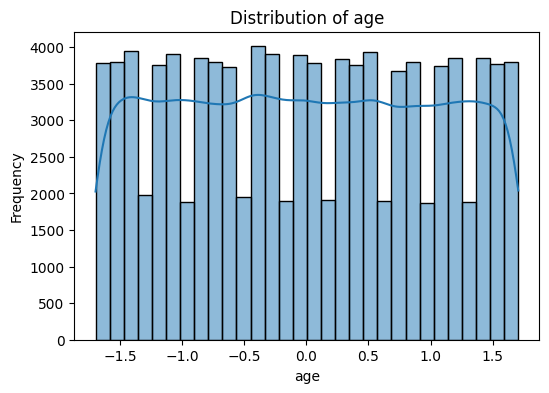

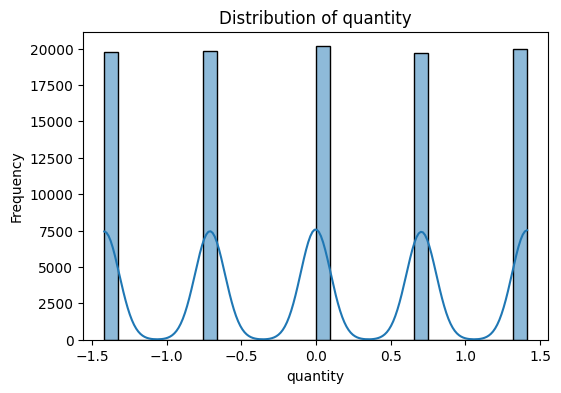

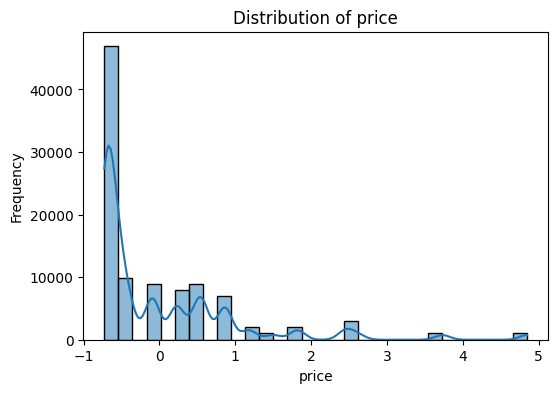

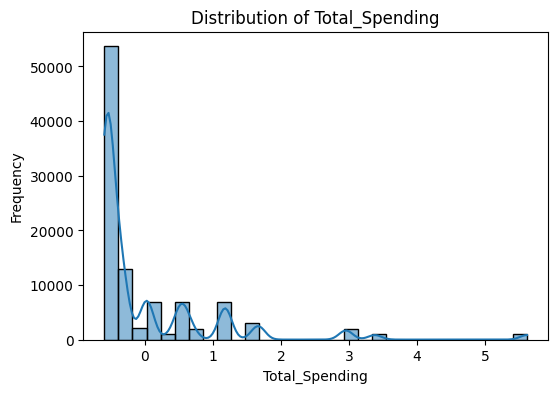

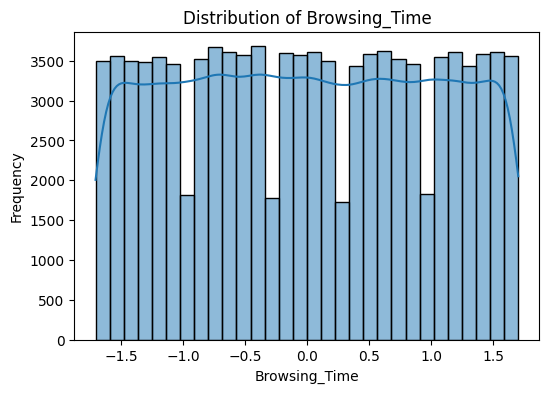

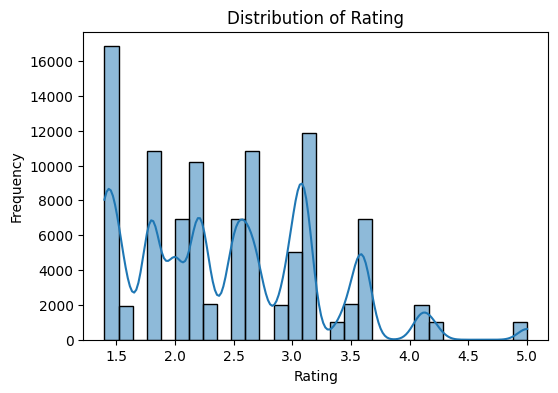

In [11]:
# ==========================================
# Distribution of Numerical Features
# ==========================================

numerical_features = [
    "age",
    "quantity",
    "price",
    "Total_Spending",
    "Browsing_Time",
    "Rating"
]

for feature in numerical_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

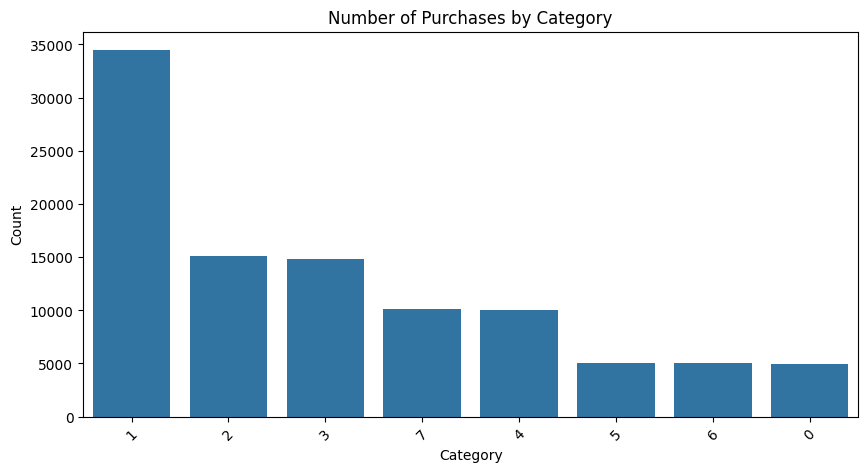

In [12]:
# ==========================================
# Product Category Distribution
# ==========================================

plt.figure(figsize=(10,5))

sns.countplot(
    x=df["category"],
    order=df["category"].value_counts().index
)

plt.title("Number of Purchases by Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

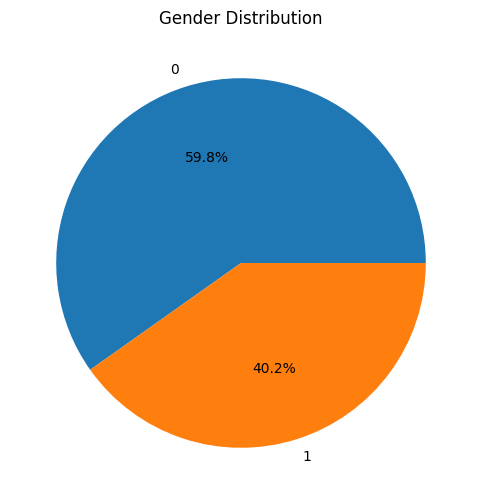

In [13]:
# ==========================================
# Gender Distribution
# ==========================================

plt.figure(figsize=(6,6))

df["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.ylabel("")

plt.show()

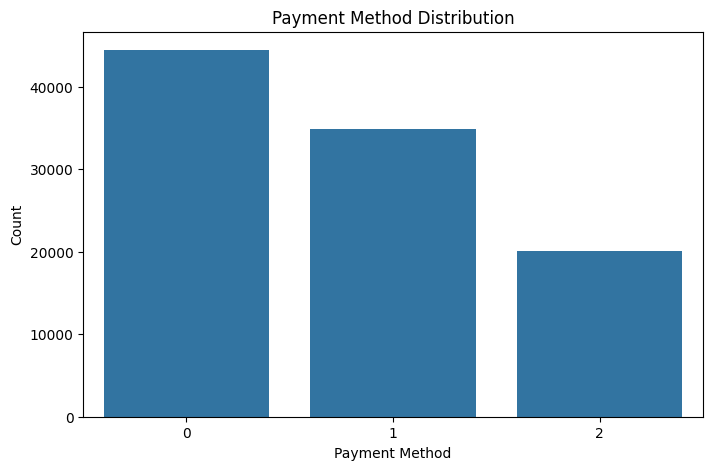

In [14]:
# ==========================================
# Payment Method Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(
    x=df["payment_method"],
    order=df["payment_method"].value_counts().index
)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Count")

plt.show()

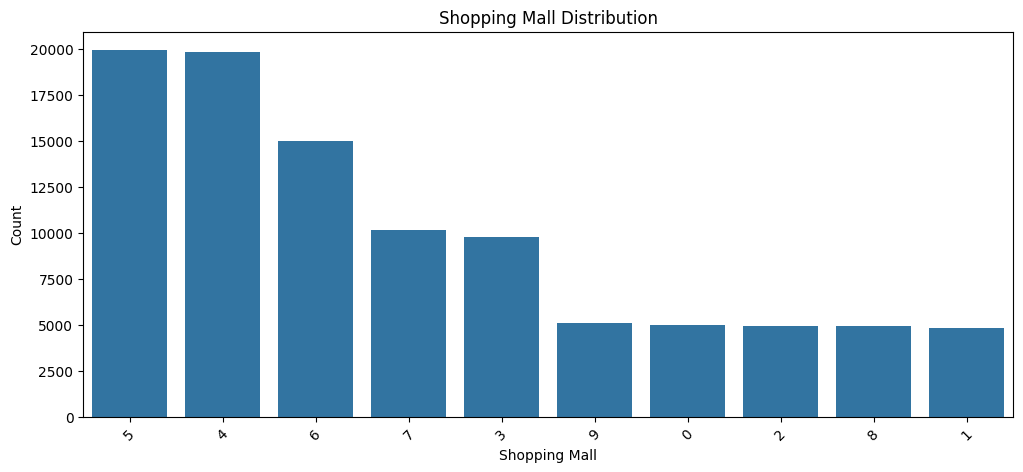

In [15]:
# ==========================================
# Shopping Mall Distribution
# ==========================================

plt.figure(figsize=(12,5))

sns.countplot(
    x=df["shopping_mall"],
    order=df["shopping_mall"].value_counts().index
)

plt.title("Shopping Mall Distribution")
plt.xlabel("Shopping Mall")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

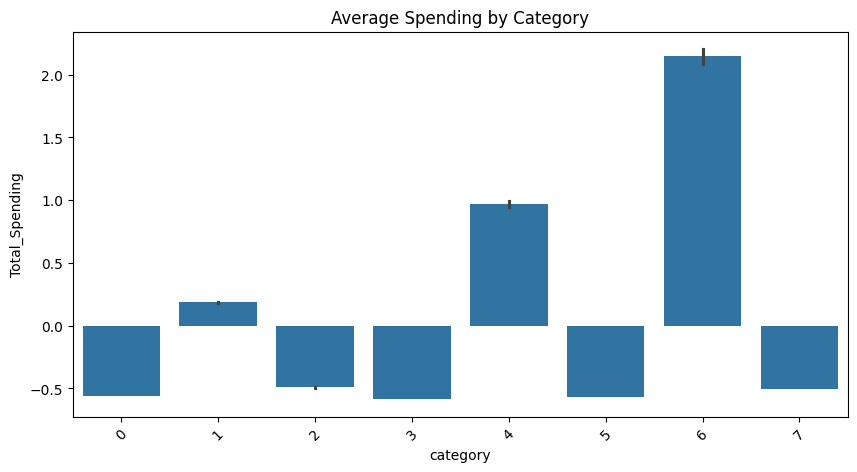

In [16]:
# ==========================================
# Total Spending by Category
# ==========================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="category",
    y="Total_Spending",
    estimator=np.mean
)

plt.title("Average Spending by Category")

plt.xticks(rotation=45)

plt.show()

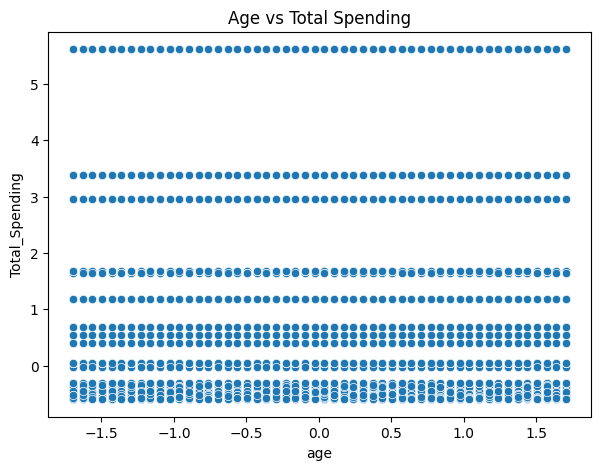

In [17]:
# ==========================================
# Age vs Total Spending
# ==========================================

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="age",
    y="Total_Spending"
)

plt.title("Age vs Total Spending")

plt.show()

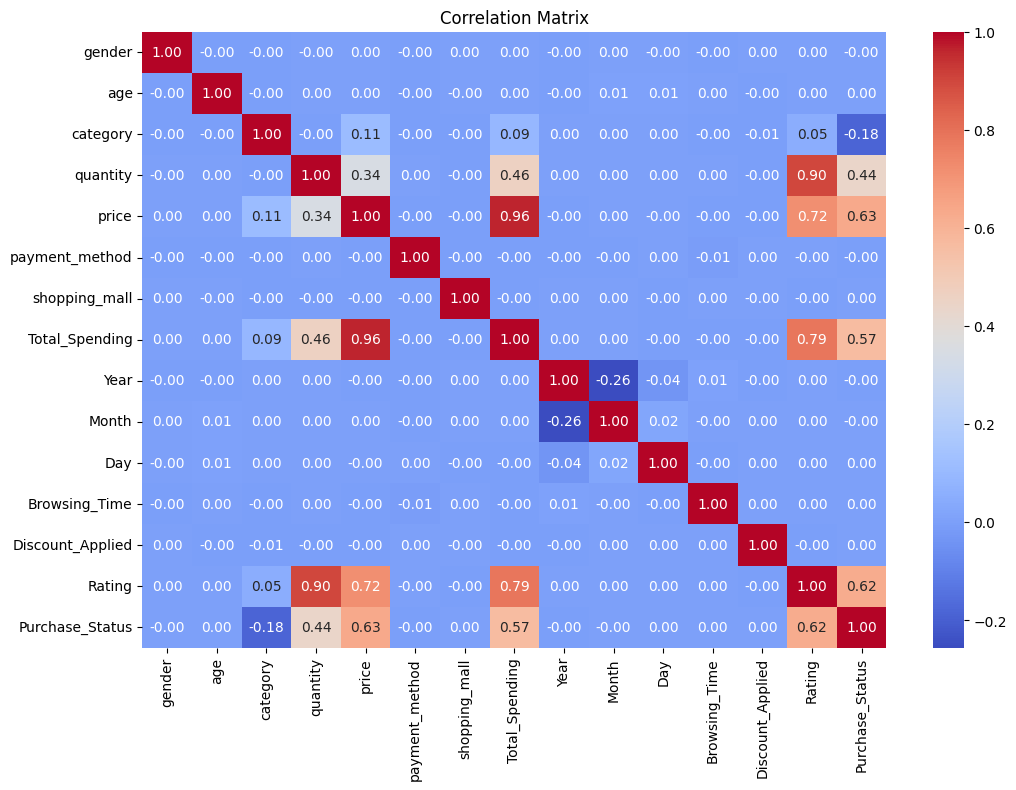

In [18]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

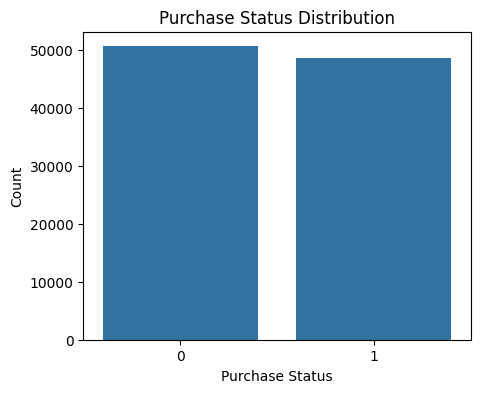

In [19]:
# ==========================================
# Purchase Status Distribution
# ==========================================

plt.figure(figsize=(5,4))

sns.countplot(x=df["Purchase_Status"])

plt.title("Purchase Status Distribution")

plt.xlabel("Purchase Status")

plt.ylabel("Count")

plt.show()

In [20]:
# ==========================================
# Linear Regression - Rating Prediction
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Features
X = df[
    [
        "price",
        "Browsing_Time",
        "quantity",
        "Discount_Applied",
        "age",
        "category",
        "Total_Spending"
    ]
]

# Target
y = df["Rating"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

# Prediction
y_pred = linear_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("-"*35)
print("MAE :", round(mae,3))
print("MSE :", round(mse,3))
print("RMSE:", round(rmse,3))
print("R2 Score:", round(r2,3))

Linear Regression Results
-----------------------------------
MAE : 0.021
MSE : 0.001
RMSE: 0.026
R2 Score: 0.999


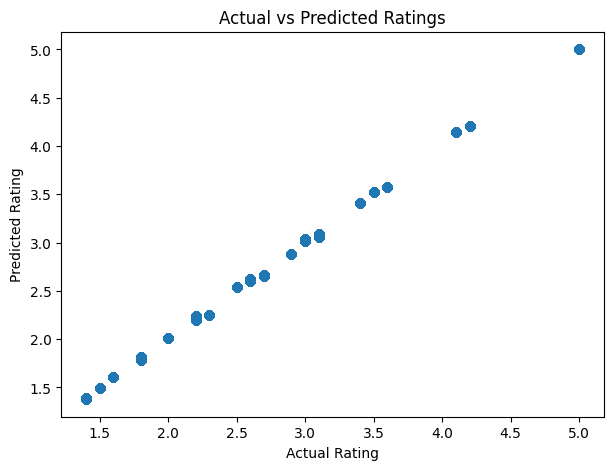

In [21]:
# ==========================================
# Actual vs Predicted Ratings
# ==========================================

plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")

plt.title("Actual vs Predicted Ratings")

plt.show()

In [22]:
# ==========================================
# Ridge Regression
# ==========================================

from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Results")
print("-"*35)
print("MAE :", round(ridge_mae,3))
print("MSE :", round(ridge_mse,3))
print("RMSE:", round(ridge_rmse,3))
print("R2 Score:", round(ridge_r2,3))

Ridge Regression Results
-----------------------------------
MAE : 0.021
MSE : 0.001
RMSE: 0.026
R2 Score: 0.999


In [23]:
# ==========================================
# Regression Comparison
# ==========================================

comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge Regression"
    ],

    "MAE":[
        mae,
        ridge_mae
    ],

    "RMSE":[
        rmse,
        ridge_rmse
    ],

    "R2 Score":[
        r2,
        ridge_r2
    ]

})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.021482,0.025537,0.998922
1,Ridge Regression,0.021479,0.025537,0.998922


In [24]:
# ==========================================
# Logistic Regression
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

X = df[
    [
        "Browsing_Time",
        "quantity",
        "Rating",
        "price",
        "Discount_Applied",
        "Total_Spending"
    ]
]

y = df["Purchase_Status"]

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

prediction=model.predict(X_test)

print("Accuracy :",accuracy_score(y_test,prediction))
print("Precision:",precision_score(y_test,prediction))
print("Recall :",recall_score(y_test,prediction))
print("F1 Score :",f1_score(y_test,prediction))

Accuracy : 1.0
Precision: 1.0
Recall : 1.0
F1 Score : 1.0


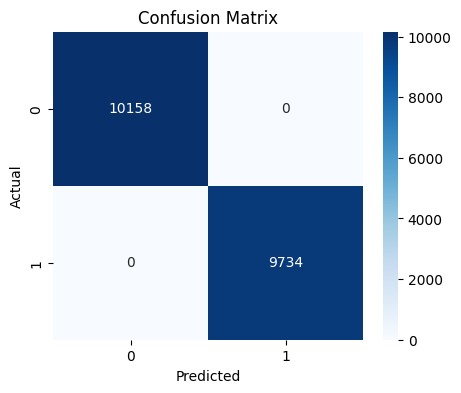

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10158
           1       1.00      1.00      1.00      9734

    accuracy                           1.00     19892
   macro avg       1.00      1.00      1.00     19892
weighted avg       1.00      1.00      1.00     19892



In [25]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test,prediction)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

print(classification_report(y_test,prediction))

In [26]:
# ==========================================
# ROC-AUC Score
# ==========================================

from sklearn.metrics import roc_auc_score

prob=model.predict_proba(X_test)[:,1]

roc=roc_auc_score(y_test,prob)

print("ROC-AUC Score:",round(roc,3))

ROC-AUC Score: 1.0


In [27]:
# ==========================================
# K-Means Clustering
# ==========================================

from sklearn.cluster import KMeans

cluster_features = df[
    [
        "age",
        "quantity",
        "price",
        "Browsing_Time",
        "Total_Spending",
        "Rating"
    ]
]

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(cluster_features)

print("Cluster Counts:")
print(df["Cluster"].value_counts())

Cluster Counts:
Cluster
3    35336
1    28624
0    28451
2     7046
Name: count, dtype: int64


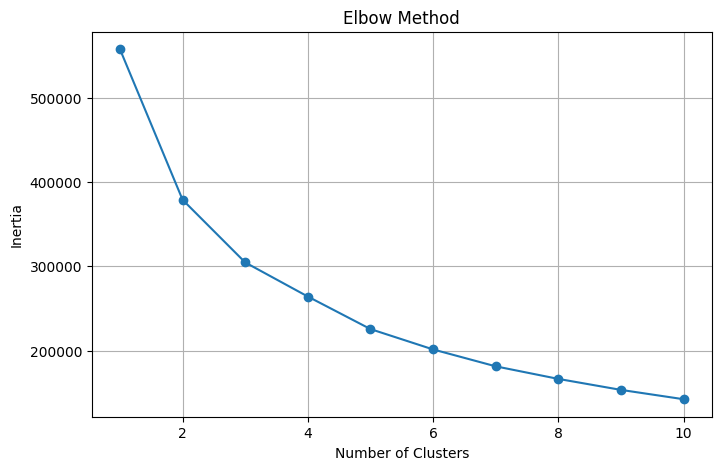

In [28]:
# ==========================================
# Elbow Method
# ==========================================

inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(cluster_features)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(True)

plt.show()

In [29]:
# ==========================================
# Silhouette Score
# ==========================================

from sklearn.metrics import silhouette_score

score = silhouette_score(
    cluster_features,
    df["Cluster"]
)

print("Silhouette Score:", round(score,3))

Silhouette Score: 0.221


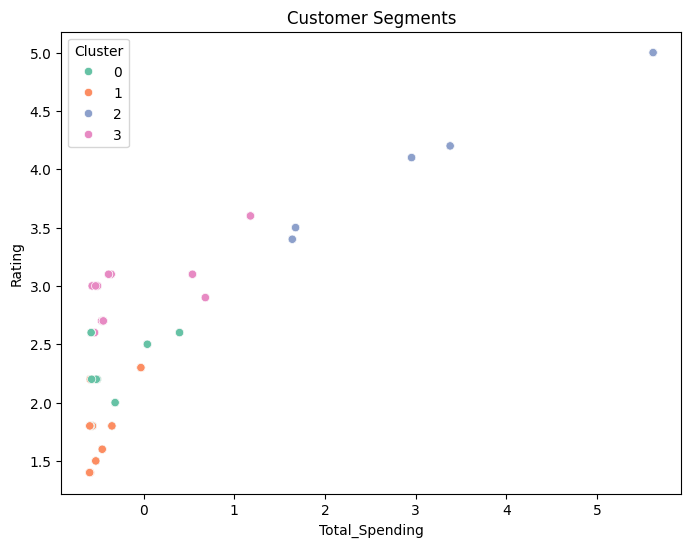

In [30]:
# ==========================================
# Cluster Visualization
# ==========================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Total_Spending",
    y="Rating",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments")

plt.show()

In [31]:
# ==========================================
# GridSearchCV for Ridge
# ==========================================

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

parameters = {
    "alpha":[
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

grid = GridSearchCV(
    Ridge(),
    parameters,
    cv=5,
    scoring="r2"
)

grid.fit(X_train,y_train)

print("Best Alpha:",grid.best_params_)
print("Best Score:",grid.best_score_)

Best Alpha: {'alpha': 0.01}
Best Score: 0.5862490928068774


In [32]:
# ==========================================
# GridSearchCV for Logistic Regression
# ==========================================

parameters = {

    "C":[0.01,0.1,1,10],

    "solver":[
        "liblinear",
        "lbfgs"
    ],

    "max_iter":[
        100,
        500,
        1000
    ]

}

grid_logistic = GridSearchCV(

    LogisticRegression(),

    parameters,

    cv=5,

    scoring="accuracy"

)

grid_logistic.fit(X_train,y_train)

print("Best Parameters")

print(grid_logistic.best_params_)

print("\nBest Accuracy")

print(grid_logistic.best_score_)

Best Parameters
{'C': 1, 'max_iter': 100, 'solver': 'liblinear'}

Best Accuracy
1.0


In [33]:
# ==========================================
# Model Comparison
# ==========================================

comparison = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Ridge Regression",

        "Logistic Regression",

        "K-Means"

    ],

    "Metric":[

        f"R² = {round(r2,3)}",

        f"R² = {round(ridge_r2,3)}",

        f"Accuracy = {round(accuracy_score(y_test,prediction),3)}",

        f"Silhouette = {round(score,3)}"

    ]

})

comparison

,Model,Metric
0,Linear Regression,R² = 0.999
1,Ridge Regression,R² = 0.999
2,Logistic Regression,Accuracy = 1.0
3,K-Means,Silhouette = 0.221


In [34]:
# ==========================================
# Business Interpretation
# ==========================================

print("Business Interpretation")
print("="*60)

print("""
1. Linear Regression predicts customer ratings.

2. Ridge Regression improves prediction by reducing overfitting.

3. Logistic Regression predicts whether a customer is
   likely to purchase a product.

4. K-Means segments customers into different groups.

5. Customer segmentation helps businesses create
   personalized marketing campaigns.

6. Customers with higher spending and ratings
   are valuable customers.

7. Businesses can recommend products based on
   predicted ratings and purchase probability.
""")

Business Interpretation

1. Linear Regression predicts customer ratings.

2. Ridge Regression improves prediction by reducing overfitting.

3. Logistic Regression predicts whether a customer is
   likely to purchase a product.

4. K-Means segments customers into different groups.

5. Customer segmentation helps businesses create
   personalized marketing campaigns.

6. Customers with higher spending and ratings
   are valuable customers.

7. Businesses can recommend products based on
   predicted ratings and purchase probability.



In [35]:
# ==========================================
# Final Conclusion
# ==========================================

print("FINAL CONCLUSION")
print("="*60)

print("""
The project successfully implemented multiple machine
learning algorithms for an e-commerce recommendation system.

Linear Regression and Ridge Regression were used
for Rating Prediction.

Logistic Regression predicted Purchase Status.

K-Means segmented customers into meaningful groups.

Hyperparameter tuning improved model performance.

These models can help businesses improve
recommendations, customer targeting,
and sales conversion.
""")

FINAL CONCLUSION

The project successfully implemented multiple machine
learning algorithms for an e-commerce recommendation system.

Linear Regression and Ridge Regression were used
for Rating Prediction.

Logistic Regression predicted Purchase Status.

K-Means segmented customers into meaningful groups.

Hyperparameter tuning improved model performance.

These models can help businesses improve
recommendations, customer targeting,
and sales conversion.

